In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_data.csv")
df

,Unnamed: 0,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,2,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
2,3,362,6.096048,7.417137,No,No,No,Roots and tubers
3,5,178,6.426840,7.346881,No,No,No,Fodder plants
4,7,128,5.609925,6.615464,No,No,No,Oilcrops
...,...,...,...,...,...,...,...,...
7751,13855,1180,-5.282243,31.366502,No,No,Yes,Fodder plants
7752,13856,1190,-5.280960,31.366483,No,No,Yes,Fruits
7753,13857,1188,-5.281934,31.367701,No,No,No,Fodder plants
7754,13864,879,-3.795245,33.273638,No,No,Yes,Fodder plants


In [3]:
df.drop(df.columns[0], axis = 1, inplace = True)
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
2,362,6.096048,7.417137,No,No,No,Roots and tubers
3,178,6.426840,7.346881,No,No,No,Fodder plants
4,128,5.609925,6.615464,No,No,No,Oilcrops
...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants


In [4]:
from sklearn.cluster import KMeans

In [5]:
coords = df[['longitude', 'latitude']]
wcss = []
k_range = range(1, 11)

In [6]:
for k in k_range:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)
    kmeans.fit(coords)
    wcss.append(kmeans.inertia_)

In [7]:
wcss

[3878662.4907204346,
 1148267.7542247004,
 816699.0336768836,
 573851.707575937,
 452481.63026972534,
 350302.3296543909,
 293388.05750204204,
 230768.37656869867,
 183981.1061522603,
 158348.10847175797]

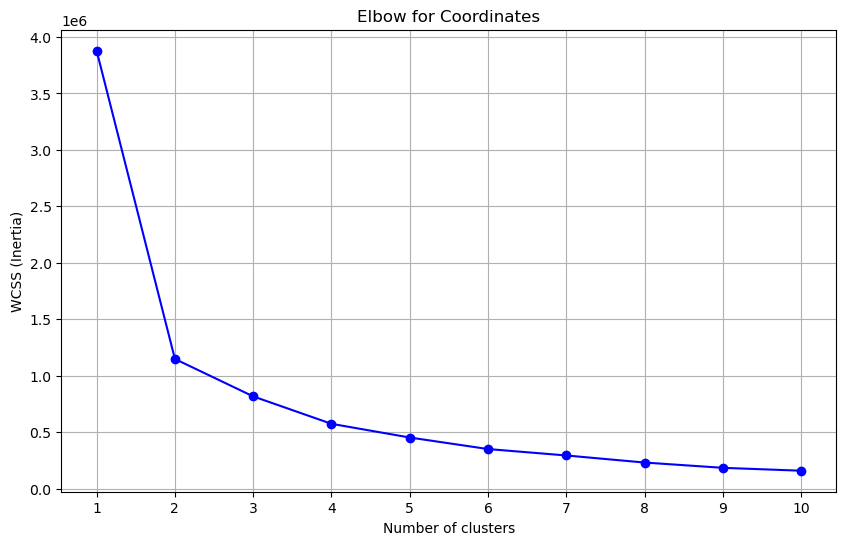

In [8]:
plt.figure(figsize = (10, 6))
plt.plot(k_range, wcss, marker = 'o', linestyle = '-', color = 'b')
plt.title('Elbow for Coordinates')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)') #Measure of how 'close' points are
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
#Applying DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 1.5, min_samples = 15)
cluster_labels = dbscan.fit_predict(coords)

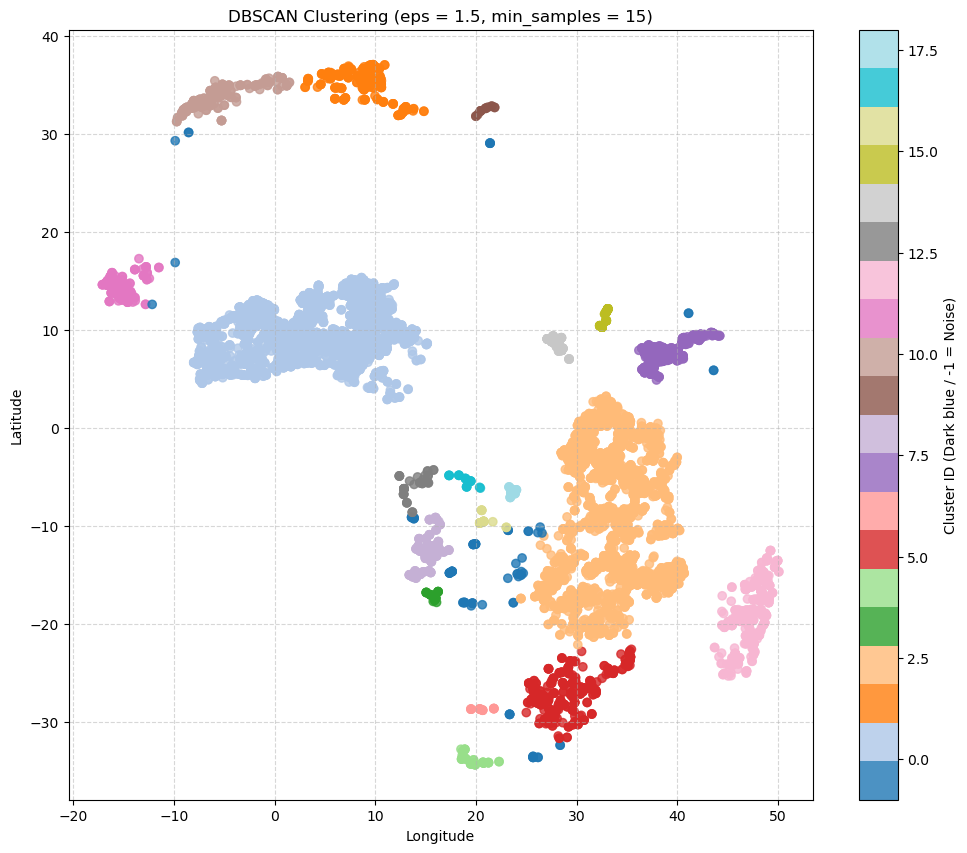

In [10]:
plt.figure(figsize = (12, 10))
scatter = plt.scatter(df['longitude'], df['latitude'], c = cluster_labels, cmap = 'tab20', alpha = 0.8)
plt.title(f'DBSCAN Clustering (eps = {dbscan.eps}, min_samples = {dbscan.min_samples})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(scatter, label = 'Cluster ID (Dark blue / -1 = Noise)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.savefig('clusters_before_knn.png')
plt.show()

In [11]:
print(cluster_labels)
len(cluster_labels)

[ 0  0  0 ... 10 10  8]


7756

In [12]:
distinct_clusters = np.unique(cluster_labels)
print(distinct_clusters)

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


In [13]:
#Saving KNN Model
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors= 1)
knn.fit(coords, cluster_labels)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
import joblib
joblib.dump(knn, 'knn_spatial_mapper.pkl')

['knn_spatial_mapper.pkl']

In [16]:
#One-Hot Encoding the coordinate data
df['geo_clusters'] = cluster_labels
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers,0
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0
2,362,6.096048,7.417137,No,No,No,Roots and tubers,0
3,178,6.426840,7.346881,No,No,No,Fodder plants,0
4,128,5.609925,6.615464,No,No,No,Oilcrops,0
...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants,10
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits,10
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants,10
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants,10


In [17]:
df_encoded = pd.get_dummies(df, columns = ['geo_clusters'], prefix = 'cluster')
df_encoded

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,cluster_-1,cluster_0,cluster_1,...,cluster_9,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,362,6.096048,7.417137,No,No,No,Roots and tubers,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,178,6.426840,7.346881,No,No,No,Fodder plants,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,128,5.609925,6.615464,No,No,No,Oilcrops,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [18]:
df_encoded.drop(columns = ['longitude', 'latitude'], inplace = True)
df_encoded

,altitude,srf_salt,srf_crust,bare_soil,crop_type,cluster_-1,cluster_0,cluster_1,cluster_2,cluster_3,...,cluster_9,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18
0,387,No,No,Yes,Roots and tubers,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,370,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,362,No,No,No,Roots and tubers,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,178,No,No,No,Fodder plants,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,128,No,No,No,Oilcrops,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7751,1180,No,No,Yes,Fodder plants,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7752,1190,No,No,Yes,Fruits,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7753,1188,No,No,No,Fodder plants,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7754,879,No,No,Yes,Fodder plants,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [19]:
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers,0
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0
2,362,6.096048,7.417137,No,No,No,Roots and tubers,0
3,178,6.426840,7.346881,No,No,No,Fodder plants,0
4,128,5.609925,6.615464,No,No,No,Oilcrops,0
...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants,10
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits,10
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants,10
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants,10


In [20]:
#OHE
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoder.fit(df[['geo_clusters']])

joblib.dump(encoder, 'cluster_encoder.pkl')

['cluster_encoder.pkl']

In [21]:
#Standard scaler for altitude
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['scaled_altitude'] = scaler.fit_transform(df[['altitude']])

joblib.dump(scaler, 'altitude_scaler.pkl')

['altitude_scaler.pkl']

In [22]:
#Mapping the Yes/No columns
binary_map = {'Yes' : 1, 'No' : 0}
df['srf_salt'] = df['srf_salt'].map(binary_map)
df['srf_crust'] = df['srf_crust'].map(binary_map)
df['bare_soil'] = df['bare_soil'].map(binary_map)
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude
0,387,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947
1,370,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111
2,362,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364
3,178,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195
4,128,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030
...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808
7752,1190,-5.280960,31.366483,0,0,1,Fruits,10,0.760375
7753,1188,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061
7754,879,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144


In [23]:
#Label encoding target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit_transform(df['crop_type'])

joblib.dump(le, 'prediction_label_encoder.pkl')

['prediction_label_encoder.pkl']

In [24]:
df['crops'] = le.transform(df['crop_type'])
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude,crops
0,387,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947,8
1,370,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111,9
2,362,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364,8
3,178,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195,2
4,128,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030,5
...,...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808,2
7752,1190,-5.280960,31.366483,0,0,1,Fruits,10,0.760375,3
7753,1188,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061,2
7754,879,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144,2


In [25]:
df['crop_type'].value_counts()

crop_type
Cereals                                                  4791
Roots and tubers                                          828
Pulses                                                    412
Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)     405
Oilcrops                                                  368
Fruits                                                    304
Other crops (e.g., rubber)                                216
Fibre crops                                               172
Fodder plants                                             155
Vegetables                                                 91
Nursery stock                                              14
Name: count, dtype: int64

In [26]:
df_final = df.copy()
df_final

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude,crops
0,387,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947,8
1,370,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111,9
2,362,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364,8
3,178,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195,2
4,128,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030,5
...,...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808,2
7752,1190,-5.280960,31.366483,0,0,1,Fruits,10,0.760375,3
7753,1188,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061,2
7754,879,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144,2


In [27]:
df_final.drop(columns = ['altitude'], inplace = True)
df_final

,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude,crops
0,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947,8
1,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111,9
2,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364,8
3,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195,2
4,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030,5
...,...,...,...,...,...,...,...,...,...
7751,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808,2
7752,-5.280960,31.366483,0,0,1,Fruits,10,0.760375,3
7753,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061,2
7754,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144,2


In [28]:
x = df_final.iloc[:,:5]
y = df_final['crop_type']

In [29]:
df_final.columns

Index(['longitude', 'latitude', 'srf_salt', 'srf_crust', 'bare_soil',
       'crop_type', 'geo_clusters', 'scaled_altitude', 'crops'],
      dtype='object')

In [30]:
x = x.join(df_final['geo_clusters'])
x = x.join(df_final['scaled_altitude'])
x

,longitude,latitude,srf_salt,srf_crust,bare_soil,geo_clusters,scaled_altitude
0,6.094781,7.423652,0,0,1,0,-0.569947
1,6.099892,7.418512,0,0,0,0,-0.598111
2,6.096048,7.417137,0,0,0,0,-0.611364
3,6.426840,7.346881,0,0,0,0,-0.916195
4,5.609925,6.615464,0,0,0,0,-0.999030
...,...,...,...,...,...,...,...
7751,-5.282243,31.366502,0,0,1,10,0.743808
7752,-5.280960,31.366483,0,0,1,10,0.760375
7753,-5.281934,31.367701,0,0,0,10,0.757061
7754,-3.795245,33.273638,0,0,1,10,0.245144


In [31]:
y = le.transform(df_final['crop_type'])
y

array([8, 9, 8, ..., 2, 2, 0])

In [32]:
df_final['crop_type'].value_counts()

crop_type
Cereals                                                  4791
Roots and tubers                                          828
Pulses                                                    412
Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)     405
Oilcrops                                                  368
Fruits                                                    304
Other crops (e.g., rubber)                                216
Fibre crops                                               172
Fodder plants                                             155
Vegetables                                                 91
Nursery stock                                              14
Name: count, dtype: int64

In [33]:
features = ['Cereals', 'Roots and tubers', 'Pulses', 'Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)', 'Oilcrops', 'Fruits', 'Fibre crops', 'Fodder plants']
df_final['crop_type'] = df_final['crop_type'].where(df_final['crop_type'].isin(features), 'Others')
df_final['crop_type'].value_counts()

crop_type
Cereals                                                  4791
Roots and tubers                                          828
Pulses                                                    412
Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)     405
Oilcrops                                                  368
Others                                                    321
Fruits                                                    304
Fibre crops                                               172
Fodder plants                                             155
Name: count, dtype: int64

In [34]:
y = None
y = le.fit_transform(df_final['crop_type'])
y

array([7, 8, 7, ..., 2, 2, 0])

In [35]:
joblib.dump(le, 'prediction_label_encoder.pkl')

['prediction_label_encoder.pkl']

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state= 42, stratify= y)

In [37]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [38]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from xgboost import XGBClassifier

In [39]:
model = XGBClassifier(
    n_estimators= 100,
    max_depth= 5,
    learning_rate= 0.1,
    objective= 'multi:softprob',
    alpha= 0
)

In [40]:
model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [41]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [42]:
score = f1_score(y_test, y_pred, average='weighted')
print(score)

0.6252023212767566


In [43]:
#Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'alpha': [0, 0.1, 0.5, 1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [44]:
base_model = XGBClassifier(objective= 'multi:softprob', random_state = 42)

random_search = RandomizedSearchCV(
    estimator = model,
    param_distributions= params,
    n_iter= 20,
    scoring='f1_weighted',
    cv=3,
    verbose= 2,
    random_state= 42,
    n_jobs= -1
)

In [45]:
print("HPT initializeing...")
random_search.fit(x_train, y_train)

HPT initializeing...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...obs=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [0, 0.1, ...], 'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [46]:
print(f"Best F-1 score achived: {random_search.best_score_}")
print(f"Best parameters to be used: {random_search.best_params_}")

Best F-1 score achived: 0.6677925143323225
Best parameters to be used: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.9, 'alpha': 0.1}


In [47]:
best_model = random_search.best_estimator_

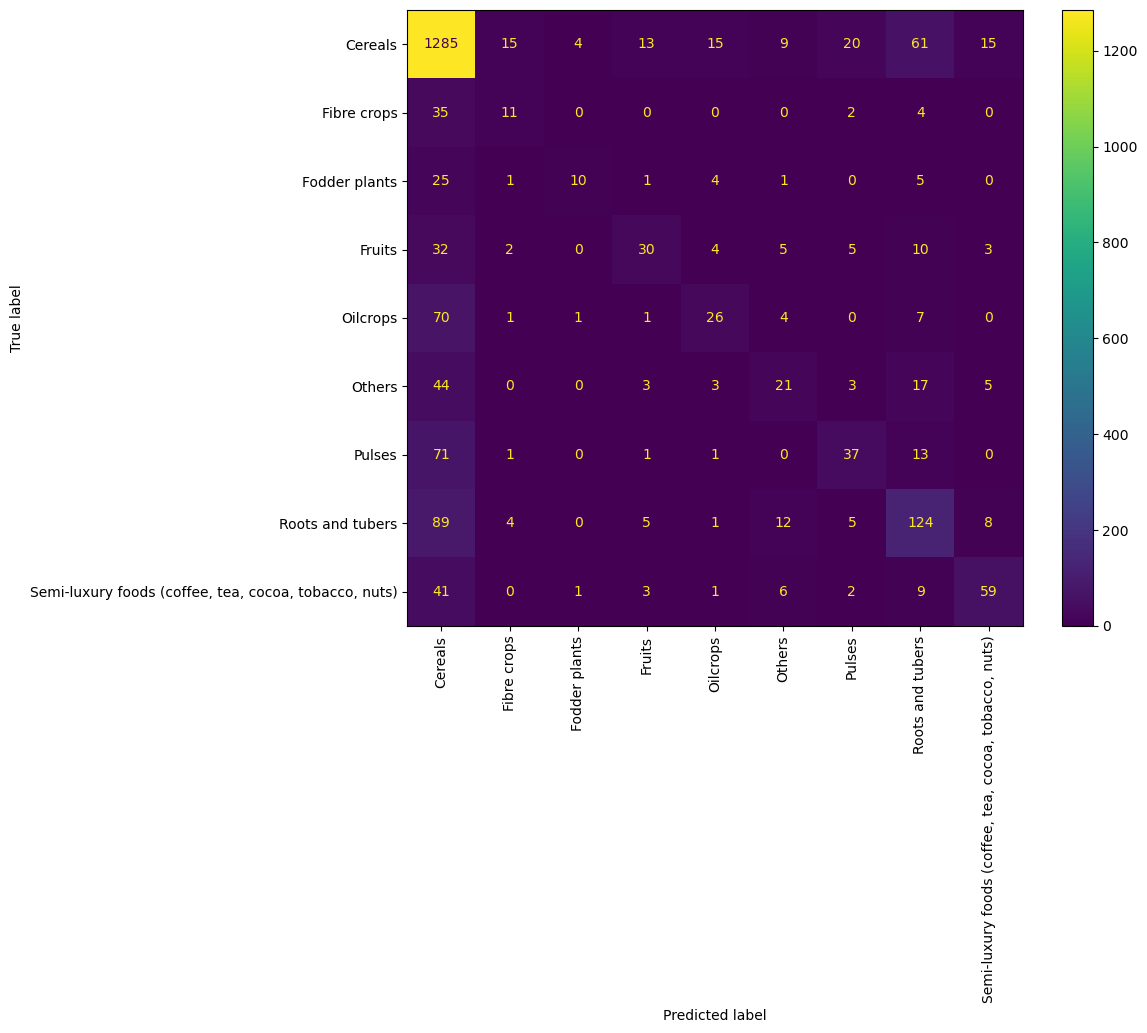

In [48]:
fig, ax = plt.subplots(figsize= (10,8))
ConfusionMatrixDisplay.from_estimator(
    best_model, x_test, y_test,
    display_labels= le.classes_,
    xticks_rotation= 'vertical',
    ax= ax
)

plt.show()

In [49]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [50]:
from imblearn.over_sampling import SMOTE
smote= SMOTE(random_state= 42)

In [51]:
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)
print(f"Original x_train rows: {len(x_train)}")
print(f"Resampled x_train rows: {len(x_train_bal)}")

Original x_train rows: 5429
Resampled x_train rows: 30186


In [52]:
best_model.fit(x_train_bal, y_train_bal)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [53]:
y_pred_bal = best_model.predict(x_test)
len(y_pred_bal)

2327

In [54]:
#F1 score after resampling minority data
new_score = f1_score(y_test, y_pred_bal, average='weighted')
print(f"New F1-Score: {new_score}")

New F1-Score: 0.5861502378927183


In [55]:
from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight= 'balanced', y= y_train)
best_model.fit(x_train, y_train, sample_weight= weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [56]:
y_pred_weighted= best_model.predict(x_test)
score_after_weight= f1_score(y_test, y_pred_weighted, average= 'weighted')
print(f"f1 score after weighting: {score_after_weight * 100}%")

f1 score after weighting: 61.17471763018811%


# Picking the most accurate model

In [57]:
best_model = random_search.best_estimator_
best_model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [58]:
y_pred = best_model.predict(x_test)

In [59]:
score = f1_score(y_test, y_pred, average='weighted')
score

0.6634463187816231

In [60]:
joblib.dump(best_model, "xgbmodel.pkl")

['xgbmodel.pkl']

In [61]:
x_test

,longitude,latitude,srf_salt,srf_crust,bare_soil,geo_clusters,scaled_altitude
1755,9.983882,12.601302,0,0,0,0,-0.593141
7625,-7.697109,32.857248,0,0,0,10,-0.447352
345,11.170637,8.113010,0,0,0,0,-0.811824
3217,31.720433,-0.452008,0,0,0,2,0.828299
4903,36.624479,-14.671734,0,0,0,2,-0.212102
...,...,...,...,...,...,...,...
2272,32.300155,-4.055993,0,0,0,2,0.649376
3980,15.684263,-12.050102,0,0,0,8,1.259038
6249,-14.696107,14.572063,0,0,0,11,-1.066954
4436,33.260990,-9.073733,0,0,0,2,1.727881
